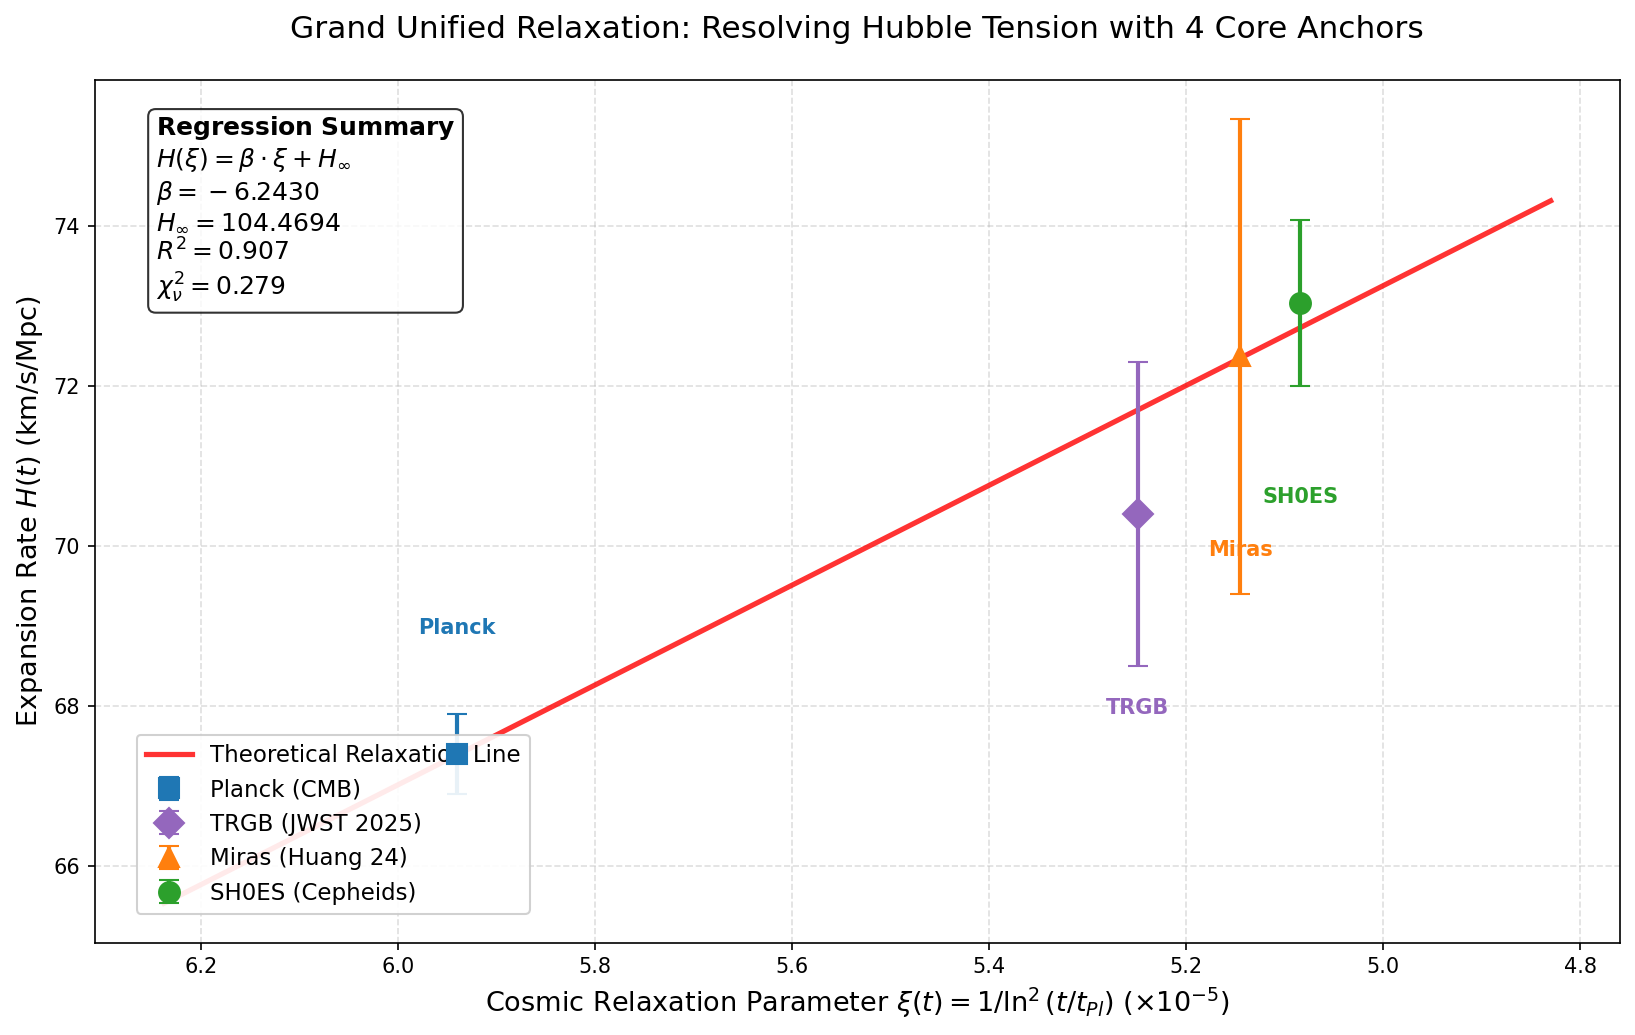

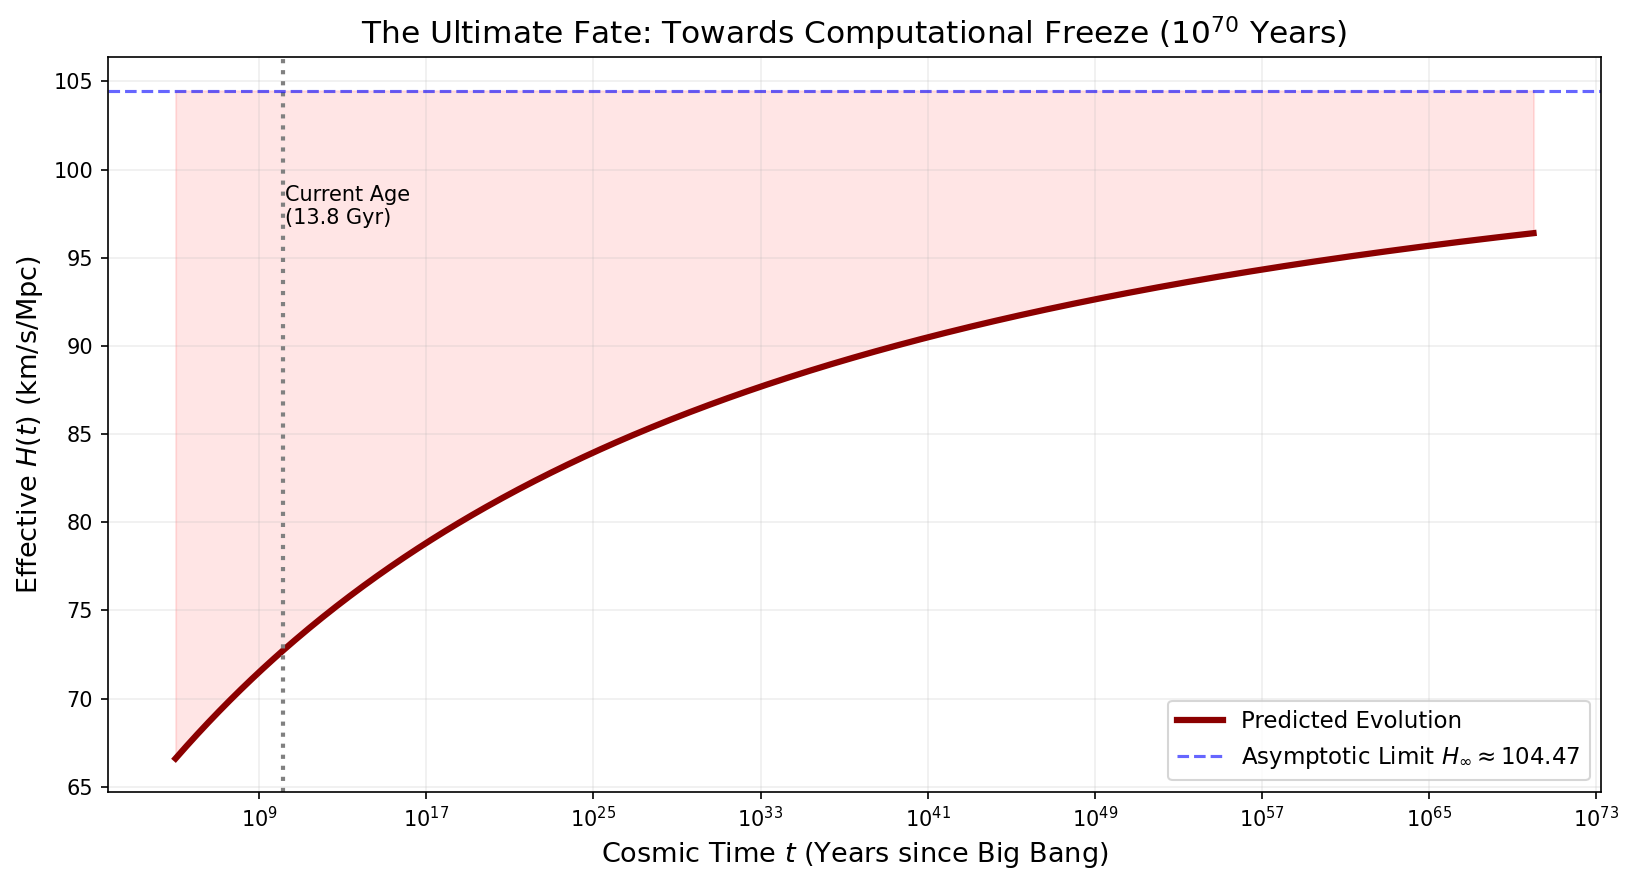

H_inf = 104.4694482261
Beta  = -6.2429729126
R2    = 0.906983
Chi2v = 0.279386


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. 物理常数与观测数据定义 (2025-2026 JWST 前沿定稿版)
t_planck_const = 5.39e-44  # 普朗克时间 (s)
sec_per_year = 3.1536e7    # 1年对应的秒数

# 四大黄金锚点
anchors = {
    'Planck (CMB)':     {'t_yr': 3.8e5,   'H': 67.4,   'err': 0.5,   'color': '#1f77b4', 'marker': 's'},
    'TRGB (JWST 2025)': {'t_yr': 1.5e9,   'H': 70.4,   'err': 1.9,   'color': '#9467bd', 'marker': 'D'},
    'Miras (Huang 24)': {'t_yr': 6.0e9,   'H': 72.37,  'err': 2.97,  'color': '#ff7f0e', 'marker': '^'},
    'SH0ES (Cepheids)': {'t_yr': 13.8e9,  'H': 73.04,  'err': 1.04,  'color': '#2ca02c', 'marker': 'o'}
}

# 转换数据为数组
names = list(anchors.keys())
t_obs = np.array([anchors[name]['t_yr'] for name in names])
H_obs = np.array([anchors[name]['H'] for name in names])
H_err = np.array([anchors[name]['err'] for name in names])

# 计算关键参量 xi = 1 / ln^2(t/t_pl)
ln_n = np.log(t_obs * sec_per_year / t_planck_const)
xi_obs = 1.0 / (ln_n**2)
xi_scaled = xi_obs * 1e5  # 放大 10^5 倍

# 线性模型
def linear_model(xi, H_inf, beta):
    return H_inf + beta * xi

# 加权拟合
popt, pcov = curve_fit(linear_model, xi_scaled, H_obs, sigma=H_err, absolute_sigma=True)
H_inf_fit, beta_fit = popt

# 计算指标
H_pred = linear_model(xi_scaled, H_inf_fit, beta_fit)
residuals = H_obs - H_pred
r2 = 1 - (np.sum(residuals**2) / np.sum((H_obs - np.mean(H_obs))**2))
chi2_v = np.sum((residuals / H_err)**2) / (len(H_obs) - 2)

# --- 绘图 1: 4 锚点回归图 ---
plt.figure(figsize=(11, 7), dpi=150)
xi_line = np.linspace(min(xi_scaled)*0.95, max(xi_scaled)*1.05, 100)
H_line = linear_model(xi_line, H_inf_fit, beta_fit)
plt.plot(xi_line, H_line, 'r-', lw=2.5, alpha=0.8, label='Theoretical Relaxation Line')

for i, name in enumerate(names):
    plt.errorbar(xi_scaled[i], H_obs[i], yerr=H_err[i], fmt=anchors[name]['marker'], 
                 color=anchors[name]['color'], label=name, markersize=10, capsize=5, elinewidth=2, zorder=5)
    offset = 1.5 if i==0 else -2.5
    plt.text(xi_scaled[i], H_obs[i] + offset, name.split()[0], 
             ha='center', fontsize=10, fontweight='bold', color=anchors[name]['color'])

plt.legend(loc='lower left', bbox_to_anchor=(0.02, 0.02), fontsize=11, framealpha=0.9)

stats_text = '\n'.join((
    r'$\mathbf{Regression\ Summary}$',
    r'$H(\xi) = \beta \cdot \xi + H_\infty$',
    f'$\\beta = {beta_fit:.4f}$',
    f'$H_\\infty = {H_inf_fit:.4f}$',
    f'$R^2 = {r2:.3f}$',
    f'$\\chi_\\nu^2 = {chi2_v:.3f}$'
))
plt.gca().text(0.04, 0.96, stats_text, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.gca().invert_xaxis() 
plt.xlabel(r'Cosmic Relaxation Parameter $\xi(t) = 1/\ln^2(t/t_{Pl})$ ($\times 10^{-5}$)', fontsize=13)
plt.ylabel(r'Expansion Rate $H(t)$ (km/s/Mpc)', fontsize=13)
plt.title('Grand Unified Relaxation: Resolving Hubble Tension with 4 Core Anchors', fontsize=15, pad=20)
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('2-hubble_4_anchors_fit.png', dpi=400)
plt.show()
plt.close()

# --- 绘图 2: 宿命预测图 ---
plt.figure(figsize=(11, 6), dpi=150)
t_future = np.logspace(5, 70, 500)
ln_n_future = np.log(t_future * sec_per_year / t_planck_const)
xi_future_scaled = (1.0 / (ln_n_future**2)) * 1e5
H_future = linear_model(xi_future_scaled, H_inf_fit, beta_fit)

plt.semilogx(t_future, H_future, color='darkred', lw=3, label='Predicted Evolution')
t_now = 13.8e9
plt.axvline(x=t_now, color='gray', ls=':', lw=2)
plt.text(t_now*1.2, H_inf_fit + (H_future[0]-H_inf_fit)*0.2, 'Current Age\n(13.8 Gyr)', fontsize=10)
plt.axhline(y=H_inf_fit, color='blue', ls='--', lw=1.5, alpha=0.6, label=fr'Asymptotic Limit $H_\infty \approx {H_inf_fit:.2f}$')
plt.fill_between(t_future, H_future, H_inf_fit, color='red', alpha=0.1)
plt.xlabel('Cosmic Time $t$ (Years since Big Bang)', fontsize=13)
plt.ylabel(r'Effective $H(t)$ (km/s/Mpc)', fontsize=13)
plt.title('The Ultimate Fate: Towards Computational Freeze ($10^{70}$ Years)', fontsize=15)
plt.grid(True, which="both", ls='-', alpha=0.2)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('3-cosmic_destiny_extrapolation.png', dpi=400)
plt.show()
plt.close()

print(f"H_inf = {H_inf_fit:.10f}")
print(f"Beta  = {beta_fit:.10f}")
print(f"R2    = {r2:.6f}")
print(f"Chi2v = {chi2_v:.6f}")